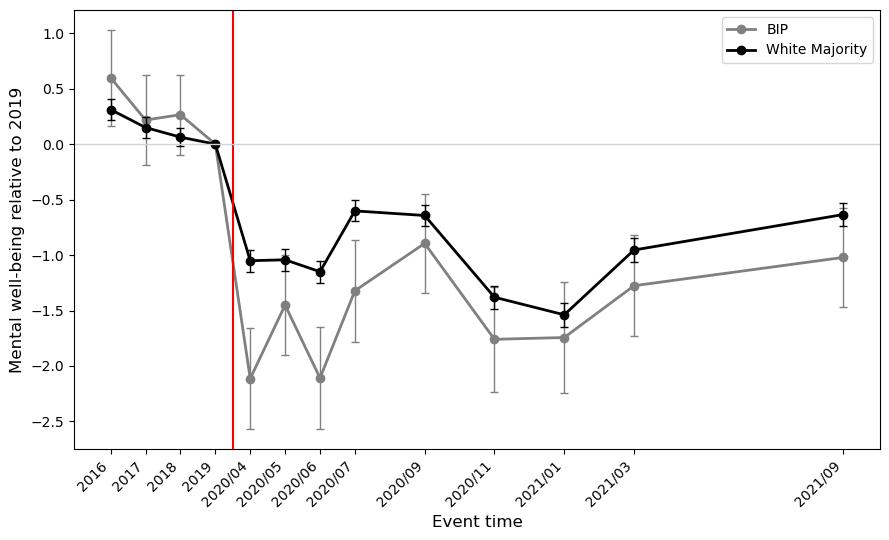

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# 讀入 Stata 匯出的資料
df = pd.read_csv("/Users/lishixue/Documents/Master thesis/Statafile/work/esbip_plotdata.csv")

# 把 evt_cat 轉成真正的 event time
event_map = {
    1: -4,   # 2016
    2: -3,   # 2017
    3: -2,   # 2018
    4: -1,   # 2019 baseline
    5: 0,    # 2020/04
    6: 1,    # 2020/05
    7: 2,    # 2020/06
    8: 3,    # 2020/07
    9: 5,    # 2020/09
    10: 7,   # 2020/11
    11: 9,   # 2021/01
    12: 11,  # 2021/03
    13: 17   # 2021/09
}

# 如果你的 csv 裡 evt 是 1~13
df["event_time"] = df["evt"].map(event_map)

# 排序
df = df.sort_values("event_time")

# 畫圖
fig, ax = plt.subplots(figsize=(9, 5.5))

# BIP：灰色
ax.plot(
    df["event_time"], df["est_bip"],
    color="gray", marker="o", linewidth=2, label="BIP"
)
ax.errorbar(
    df["event_time"], df["est_bip"],
    yerr=[
        df["est_bip"] - df["lb_bip"],
        df["ub_bip"] - df["est_bip"]
    ],
    fmt="none", color="gray", capsize=3, linewidth=1
)

# Non-BIP：黑色
ax.plot(
    df["event_time"], df["est_nonbip"],
    color="black", marker="o", linewidth=2, label="White Majority"
)
ax.errorbar(
    df["event_time"], df["est_nonbip"],
    yerr=[
        df["est_nonbip"] - df["lb_nonbip"],
        df["ub_nonbip"] - df["est_nonbip"]
    ],
    fmt="none", color="black", capsize=3, linewidth=1
)

# 紅線：畫在 -1 和 0 中間
ax.axvline(x=-0.5, color="red", linewidth=1.5)

# 0 水平線
ax.axhline(y=0, color="lightgray", linewidth=1)

# x 軸
ax.set_xticks(df["event_time"])
ax.set_xticklabels(
    ["2016", "2017", "2018", "2019", "2020/04", "2020/05", "2020/06",
     "2020/07", "2020/09", "2020/11", "2021/01", "2021/03", "2021/09"],
    rotation=45, ha="right"
)

# 標題與標籤
ax.set_title("", fontsize=14)
ax.set_xlabel("Event time", fontsize=12)
ax.set_ylabel("Mental well-being relative to 2019", fontsize=12)

# 圖例
ax.legend(frameon=True)

plt.tight_layout()
plt.savefig("/Users/lishixue/Documents/Master thesis/Statafile/Thesis2026/out/Event study/esbip_event_study.png", dpi=300, bbox_inches="tight")
plt.show()

In [2]:
import pandas as pd

# ===== 1. 路徑 =====
infile = "/Users/lishixue/Documents/Master thesis/Statafile/Thesis2026/out/Event study/ESbip_theta_table.csv"
outfile = "/Users/lishixue/Documents/Master thesis/Statafile/Thesis2026/out/Event study/ESbip_theta_table.tex"

# ===== 2. 讀資料 =====
df = pd.read_csv(infile)

# ===== 3. 整理欄位 =====
# 兼容兩種情況：
# (A) Stata 已經做好 theta_display / p_display
# (B) 只有 theta / pval / stars

df["stars"] = df["stars"].fillna("") if "stars" in df.columns else ""


if "theta" in df.columns:
        df["theta_display"] = df.apply(
            lambda row: "" if pd.isna(row["theta"]) else f"{row['theta']:.2f}{row['stars']}",
            axis=1
        )
else:
        raise ValueError("Cannot find theta_display or theta.")


if "pval" in df.columns:
        df["p_display"] = df["pval"].map(lambda x: "" if pd.isna(x) else f"{x:.2f}")
else:
        raise ValueError("Cannot find p_display or pval.")

df["theta_display"] = df["theta_display"].fillna("")
df["p_display"] = df["p_display"].fillna("")

# 只保留要放進論文的欄位
table_df = df[["period", "theta_display", "p_display"]].copy()
table_df.columns = ["Period", "Event-study coefficient", "p-value"]

# ===== 4. 轉成 LaTeX tabular =====
tabular = table_df.to_latex(
    index=False,
    escape=False,
    column_format="lcc"
)

# ===== 5. 包成完整 table 環境 =====
latex_table = rf"""
\begin{{table}}[htbp]
\centering
\caption{{Event-study estimates of the BIP--White majority gap in mental well-being}}
\label{{tab:event_study_bip}}
\small
{tabular}
\begin{{flushleft}}
\footnotesize
Notes: The table reports event-study interaction coefficients for the BIP--White majority gap in mental well-being, with 2019 omitted as the baseline period. The outcome is the April-adjusted and inverted GHQ-12 Likert score, so higher values indicate better mental well-being. A negative coefficient indicates that BIP respondents experienced a relative deterioration in mental well-being compared with the White majority. Standard errors are clustered at the individual level. *, **, and *** denote significance at the 10\%, 5\%, and 1\% levels, respectively. The row ``Joint pre-trend'' reports the p-value from the joint test of whether all pre-pandemic interaction coefficients are equal to zero.
\end{{flushleft}}
\end{{table}}
""".strip()

# ===== 6. 存檔 =====
with open(outfile, "w", encoding="utf-8") as f:
    f.write(latex_table)

print(latex_table)
print(f"\nSaved to: {outfile}")

\begin{table}[htbp]
\centering
\caption{Event-study estimates of the BIP--White majority gap in mental well-being}
\label{tab:event_study_bip}
\small
\begin{tabular}{lcc}
\toprule
Period & Event-study coefficient & p-value \\
\midrule
2019 (base) & 0.00 &  \\
2016 & 0.29 & 0.20 \\
2017 & 0.07 & 0.75 \\
2018 & 0.20 & 0.28 \\
2020/04 & -1.06*** & 0.00 \\
2020/05 & -0.41* & 0.08 \\
2020/06 & -0.96*** & 0.00 \\
2020/07 & -0.72*** & 0.00 \\
2020/09 & -0.25 & 0.28 \\
2020/11 & -0.38 & 0.12 \\
2021/01 & -0.20 & 0.43 \\
2021/03 & -0.32 & 0.18 \\
2021/09 & -0.39* & 0.10 \\
Joint pre-trend &  & 0.48 \\
\bottomrule
\end{tabular}

\begin{flushleft}
\footnotesize
Notes: The table reports event-study interaction coefficients for the BIP--White majority gap in mental well-being, with 2019 omitted as the baseline period. The outcome is the April-adjusted and inverted GHQ-12 Likert score, so higher values indicate better mental well-being. A negative coefficient indicates that BIP respondents experienc